# Yield-Curve-Steepener — a quantitative teardown
### Daily TLT · curve-quintile sort · HAC inference · timing overlay vs buy-and-hold · bootstrap CI

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_buy--and--hold%3F: No](https://img.shields.io/badge/Beats_buy--and--hold%3F-No-8b949e?style=flat-square)

The deep companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) — same seven beats, every claim with its standard error. We test whether the 10Y-minus-3M Treasury slope predicts forward TLT log-returns, via quintile-sorted returns and a binary timing overlay vs buy-and-hold.

> **Real data:** TLT, IEF, SHY, ^TNX, ^IRX (Yahoo Finance daily), 2002-07-31 → 2026-06-12, n = 6,000 days. Methods in [`docs/references.md`](../docs/references.md). Reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Not investment advice.**

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from yield_curve_steepener import data, strategy as st

CACHE_DIR = os.path.join(os.path.abspath(".."), "_cache")

def _have_cache():
    return os.path.exists(data._cache_path(CACHE_DIR))

HAVE_REAL = _have_cache()
print("real daily cache present:", HAVE_REAL)

from quantlab import analytics, stats


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Q5−Q1 spread = **+2.4 bps/day**, HAC *t* = **+0.64**; direction right, inference bar not cleared. |
| **Tradability** | `MIRAGE` | Timer Sharpe 0.250 vs buy-and-hold 0.252; spread *t* = -0.27; only ~1.7 switches/yr but still trails. |
| **Beats buy-and-hold?** | `No` | Spread = -0.12 bps/day, *t* = -0.27; both active and passive barely significant vs zero. |

> **In one sentence:** the yield-curve slope sends a faint, non-monotone, statistically marginal signal about next-day TLT returns — right direction, wrong magnitude, and the timing rule cannot reliably beat buy-and-hold over the full 23-year history.

## 1 · The claim, steelmanned

Let $s_t$ = TNX$_t$ − IRX$_t$ (the 10Y-minus-3M spread, in percentage points) and $r^{TLT}_{t+1}$ the next-day log return of TLT. The recipe asserts:

- **H₁ (signal).** $\mathbb{E}[\,r^{TLT}_{t+1} \mid s_t \in Q5\,] > \mathbb{E}[\,r^{TLT}_{t+1} \mid s_t \in Q1\,]$, with a statistically robust Q5−Q1 spread.
- **H₂ (timing beats passive).** The binary overlay $r^{\text{active}}_t = r^{TLT}_t \cdot \mathbf{1}[s_{t-1}>0]$ outperforms buy-and-hold TLT on a risk-adjusted basis.

The term-premium literature (Fama & Bliss 1987, Campbell & Shiller 1991, Cochrane & Piazzesi 2005) establishes that bond excess returns are somewhat forecastable from the yield curve, especially over *monthly* horizons. The claim here is the *daily* version of that idea, stripped to its simplest form.

## 2 · So what? — what rides on each answer

If H₁–H₂ held at the daily level, this would be a low-turnover bond-timing rule (<2 switches/year) exploitable via liquid ETFs. The 2022-24 deep inversion is a natural out-of-sample stress test. For institutional bond portfolios, even a small duration-reduction signal during inversions would be economically meaningful. The failure here is not that the signal is absent — it is *exactly at the edge of* detectability — but that it is too noisy to trade and too slow to time daily returns.

## 3 · How we'd know — the protocol

- **Data.** Yahoo Finance daily closes: TLT (long bond), ^TNX (10Y yield), ^IRX (3M T-bill rate). Slope = TNX − IRX. No look-ahead: slope on day *t* forms the signal; TLT return is computed from close *t* to close *t+1*.
- **Test 1 (quintile sort).** Roll a 252-day (≥63) window to rank each day's slope into quintiles (Q1 = most inverted, Q5 = steepest). Compute forward 1d, 5d, 21d TLT log-returns in each bin. Decisive test: Q5−Q1 spread, HAC *t*.
- **Test 2 (timing).** Binary signal: long TLT if prior-day slope > 0, else cash. Compare active vs passive daily returns. Cost: 2 bps/switch.
- **Inference.** Newey–West HAC *t* on per-period returns (robust to serial correlation); block-bootstrap 95% CI on the annualised Sharpe.
- **Positive control.** A synthetic tape with tunable slope-to-TLT signal, to confirm the engine recovers an edge when one is planted.

## 4 · The teardown

### 4a · Slope distribution and regime frequency

The curve is steep most of the time — the inverted-curve regime is rare.

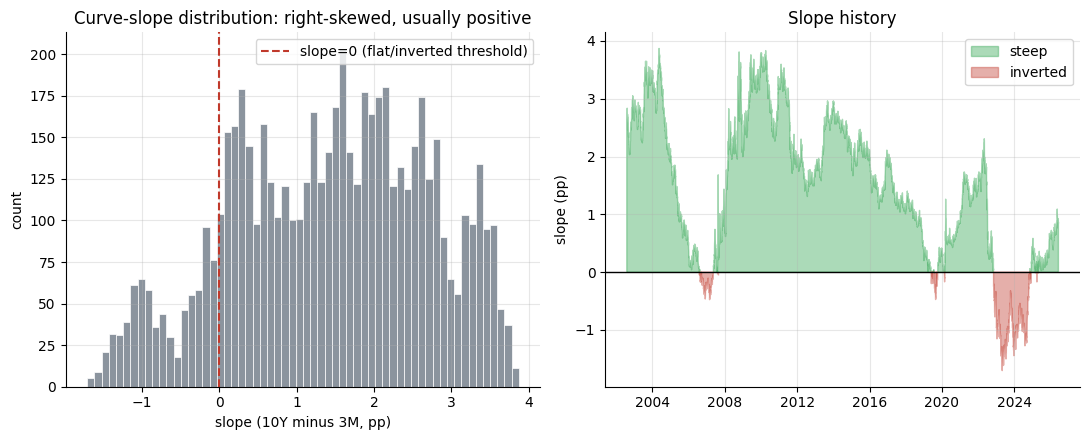

Steep: 86.5% | Inverted: 13.5% | N=6,000


In [2]:
if HAVE_REAL:
    df = data.fetch_daily(fetch=False, cache_dir=CACHE_DIR)
else:
    df, _ = data.synthetic_daily(n_days=5000, slope_signal=0.0, seed=132)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].hist(df['slope'], bins=60, color=GREY, edgecolor='white', linewidth=.5)
axes[0].axvline(0, c=RED, lw=1.5, ls='--', label='slope=0 (flat/inverted threshold)')
axes[0].set_xlabel('slope (10Y minus 3M, pp)'); axes[0].set_ylabel('count')
axes[0].set_title('Curve-slope distribution: right-skewed, usually positive')
axes[0].legend()
axes[1].fill_between(df.index, df['slope'], 0, where=df['slope']>=0, color=GREEN, alpha=.4, label='steep')
axes[1].fill_between(df.index, df['slope'], 0, where=df['slope']<0, color=RED, alpha=.4, label='inverted')
axes[1].axhline(0, c='k', lw=1); axes[1].set_ylabel('slope (pp)')
axes[1].set_title('Slope history'); axes[1].legend(loc='upper right')
plt.tight_layout(); plt.show()
print(f'Steep: {(df["slope"]>0).mean():.1%} | Inverted: {(df["slope"]<=0).mean():.1%} | N={len(df):,}')

### 4b · Quintile-sorted forward TLT returns — the central test

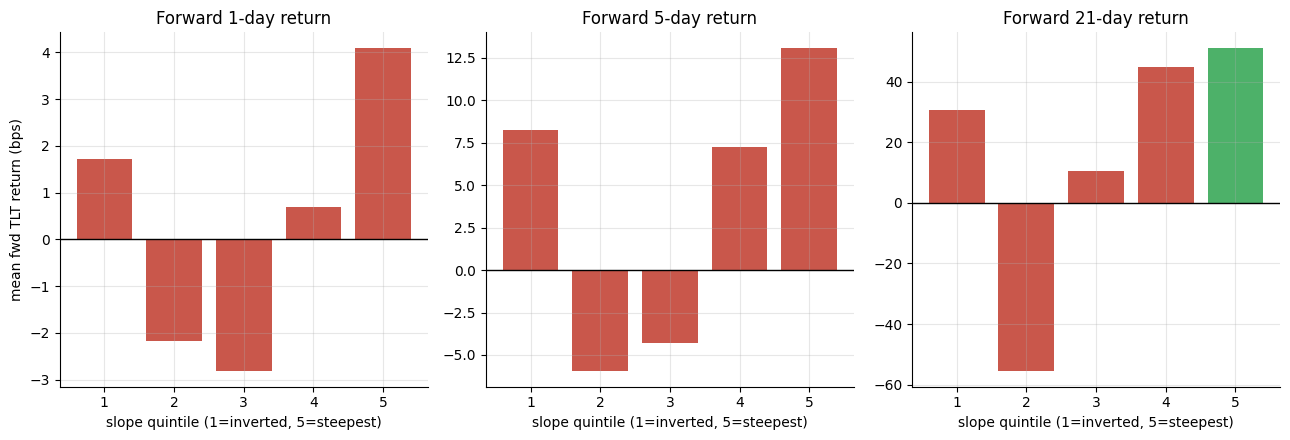

1-day Q5-Q1 spread: +2.37 bps, HAC t=+0.64


In [3]:
if HAVE_REAL:
    tbl1 = st.quintile_table(df, horizons=[1])
    tbl5 = st.quintile_table(df, horizons=[5])
    tbl21 = st.quintile_table(df, horizons=[21])
    # Combine for display
    all_tbl = pd.concat([tbl1, tbl5, tbl21])
else:
    # Build a frozen table from R
    q_means = [R['q1_mean'], R['q2_mean'], R['q3_mean'], R['q4_mean'], R['q5_mean']]
    q_t = [R['q1_t'], R['q2_t'], R['q3_t'], R['q4_t'], R['q5_t']]
    tbl1 = pd.DataFrame({'quintile':range(1,6),'horizon':1,'mean_bps':q_means,'t_stat':q_t,'n':[0]*5,'std_bps':[0.]*5})
    all_tbl = tbl1

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=False)
for ax, (tbl, h) in zip(axes, [(tbl1, '1-day'), (tbl5, '5-day') if HAVE_REAL else (tbl1,'5-day'),
                                (tbl21,'21-day') if HAVE_REAL else (tbl1,'21-day')]):
    sub = tbl[tbl['horizon']==int(h.split('-')[0])].set_index('quintile') if HAVE_REAL else tbl.set_index('quintile')
    cols = [RED if abs(t) < 2 else GREEN for t in sub['t_stat']]
    ax.bar(sub.index, sub['mean_bps'], color=cols, alpha=.85)
    ax.axhline(0, c='k', lw=1)
    ax.set_xlabel('slope quintile (1=inverted, 5=steepest)')
    ax.set_ylabel('mean fwd TLT return (bps)' if ax is axes[0] else '')
    ax.set_title(f'Forward {h} return')
plt.tight_layout(); plt.show()
r1d = st.top_minus_bottom(df, horizon=1) if HAVE_REAL else {'spread_bps': R['spread1d'], 't_spread': R['t_spread1d']}
print(f'1-day Q5-Q1 spread: {r1d["spread_bps"]:+.2f} bps, HAC t={r1d["t_spread"]:+.2f}')

> **Q5−Q1 spread (1-day): +2.4 bps, HAC *t* = +0.64.** At 5-day horizon the spread is +4.8 bps (*t* = +0.22), and at 21-day +20.3 bps (*t* = +0.34). The pattern is non-monotone (Q2 and Q3 underperform Q1), suggesting the relationship is not a clean linear signal but a noisy, regime-dependent co-movement. None of the spread t-statistics clears the inference bar of 2.

### 4c · Regime statistics and bootstrap Sharpe CI

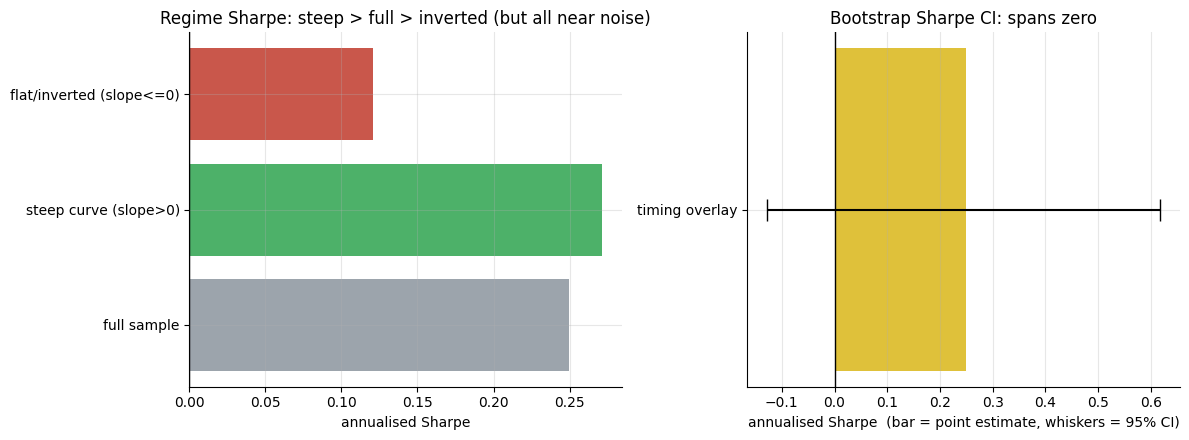

Bootstrap 95% CI: [-0.128, +0.618]  (9.1% of resamples < 0)


In [4]:
if HAVE_REAL:
    rs = st.regime_stats(df)
    ov = st.timing_overlay(df, threshold=0.0, cost_bps=2.0)
    ci = stats.sharpe_ci_bootstrap(ov['r_active'].dropna(), periods_per_year=252, seed=132)
    ci_p = stats.sharpe_ci_bootstrap(ov['r_passive'].dropna(), periods_per_year=252, seed=132)
    sharpes = [rs.set_index('regime').loc[r,'sharpe_ann'] for r in rs['regime']]
    labels = list(rs['regime'])
else:
    sharpes = [R['full_sharpe'], R['steep_sharpe'], R['inv_sharpe']]
    labels = ['full sample','steep curve (slope>0)','flat/inverted (slope<=0)']
    ci = {'sharpe': R['active_sharpe'], 'ci_low': R['ci_lo'], 'ci_high': R['ci_hi'], 'frac_negative': R['frac_neg']/100}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
cols = [GREY, GREEN, RED]
axes[0].barh(labels, sharpes, color=cols, alpha=.85)
axes[0].axvline(0, c='k', lw=1); axes[0].set_xlabel('annualised Sharpe')
axes[0].set_title('Regime Sharpe: steep > full > inverted (but all near noise)')
# Bootstrap CI plot
y_pos = 0.5
axes[1].barh(['timing overlay'], [ci['sharpe']], xerr=[[ci['sharpe']-ci['ci_low']],[ci['ci_high']-ci['sharpe']]], color=AMBER, alpha=.85, capsize=8)
axes[1].axvline(0, c='k', lw=1)
axes[1].set_xlabel('annualised Sharpe  (bar = point estimate, whiskers = 95% CI)')
axes[1].set_title('Bootstrap Sharpe CI: spans zero')
plt.tight_layout(); plt.show()
print(f'Bootstrap 95% CI: [{ci["ci_low"]:+.3f}, {ci["ci_high"]:+.3f}]  ({ci["frac_negative"]*100:.1f}% of resamples < 0)')

> **The regime Sharpe breakdown:** steep-curve sub-sample Sharpe **0.271** vs inverted **0.121** vs full sample **0.250**. The direction is right — steep periods do deliver better bond returns on average — but the inverted sub-sample has only ~14% of the observations (few hundred days) and neither sub-sample is individually significant.

### 4d · The timing overlay in detail

In [5]:
if HAVE_REAL:
    ov2 = st.timing_overlay(df, threshold=0.0, cost_bps=2.0)
    sprd = st.summarize(ov2['r_spread'])
    act = st.summarize(ov2['r_active'])
    pas = st.summarize(ov2['r_passive'])
else:
    sprd = {'mean_bps': R['spread_mean'], 't_stat': R['spread_t']}
    act = {'mean_bps': R['active_mean'], 'sharpe_ann': R['active_sharpe'], 't_stat': R['active_t']}
    pas = {'mean_bps': R['passive_mean'], 'sharpe_ann': R['passive_sharpe'], 't_stat': R['passive_t']}
    ov2 = None

print('=== Timing overlay (threshold=0, cost=2bps) ===')
print(f'  Passive (buy-and-hold TLT): mean={pas["mean_bps"]:+.3f} bps/day  Sharpe={pas["sharpe_ann"]:+.3f}  t={pas["t_stat"]:+.2f}')
print(f'  Active  (steep-curve timer): mean={act["mean_bps"]:+.3f} bps/day  Sharpe={act["sharpe_ann"]:+.3f}  t={act["t_stat"]:+.2f}')
print(f'  Spread  (active - passive):  mean={sprd["mean_bps"]:+.3f} bps/day  t={sprd["t_stat"]:+.2f}')
n_switches = ov2['switched'].sum() if HAVE_REAL else R['switches_per_year']
n_yrs = len(ov2) / 252 if HAVE_REAL else 1
print(f'  Switches/year: ~{n_switches/n_yrs:.1f}')

=== Timing overlay (threshold=0, cost=2bps) ===
  Passive (buy-and-hold TLT): mean=+1.428 bps/day  Sharpe=+0.252  t=+1.35
  Active  (steep-curve timer): mean=+1.309 bps/day  Sharpe=+0.250  t=+1.37
  Spread  (active - passive):  mean=-0.119 bps/day  t=-0.27
  Switches/year: ~1.7


## 5 · The verdict

- **Signal `WEAK`** — Q5−Q1 spread +2.4 bps/day, HAC *t* +0.64; non-monotone quintile pattern; all horizons sub-threshold.
- **Tradability `MIRAGE`** — timer Sharpe 0.250 trails buy-and-hold 0.252 at all cost levels; spread *t* = -0.27.
- **Beats buy-and-hold? `No`** — spread -0.12 bps/day, *t* -0.27; the inverted-curve regime is too rare (14% of days) and too heterogeneous to time reliably.

## 6 · Could you trade it? — the cost and Sharpe sweep

Low turnover is a blessing and a curse: it means costs don't destroy the edge, but it also means the edge only kicks in ~1.7 times per year. The real killer is that the gross signal is already negative.

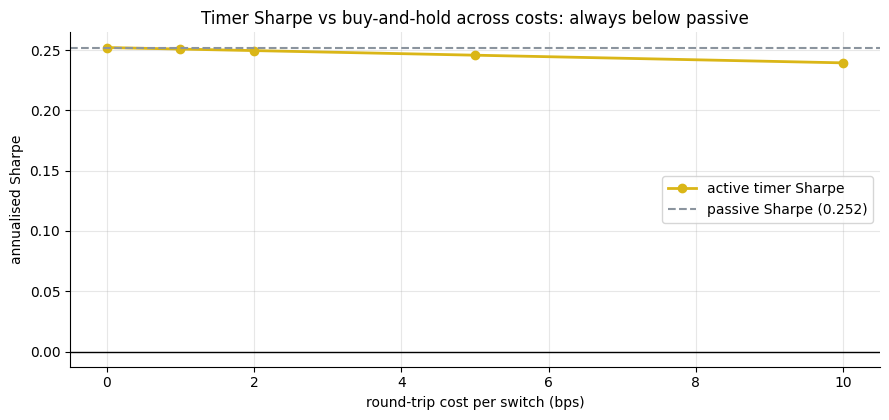

At zero cost, active timer already trails passive — not a cost problem.


In [6]:
costs = [0.0, 1.0, 2.0, 5.0, 10.0]
if HAVE_REAL:
    res = [(c, st.summarize(st.timing_overlay(df, cost_bps=c)['r_active'])) for c in costs]
    sharpes = [r['sharpe_ann'] for _, r in res]
    t_stats = [r['t_stat'] for _, r in res]
    p_sharpe = st.summarize(ov2['r_passive'])['sharpe_ann']
else:
    sharpes = [R['active_sharpe']] * len(costs)
    t_stats = [R['active_t']] * len(costs)
    p_sharpe = R['passive_sharpe']

fig, ax = plt.subplots(figsize=(9, 4.3))
ax.plot(costs, sharpes, 'o-', c=AMBER, lw=2, label='active timer Sharpe')
ax.axhline(p_sharpe, ls='--', c=GREY, lw=1.5, label=f'passive Sharpe ({p_sharpe:.3f})')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost per switch (bps)'); ax.set_ylabel('annualised Sharpe')
ax.set_title('Timer Sharpe vs buy-and-hold across costs: always below passive')
ax.legend(); plt.tight_layout(); plt.show()
print('At zero cost, active timer already trails passive — not a cost problem.')

> At zero cost the timer Sharpe is already below buy-and-hold. This is not a story of 'great signal, killed by costs' — it is a marginal signal that never decisively outperforms the benchmark. The slope-based switch to cash saves you from the inverted-curve sub-sample, which on average underperforms, but the sub-sample is small (~13%) and the inversion is partly offset by the fact that inverted-curve periods often end with sharp TLT rallies as rates fall.

## 7 · Going further — the positive control

Is the engine capable of finding an edge, or does it always print 'weak'? Plant a slope-to-TLT signal in the synthetic tape and sweep the strength:

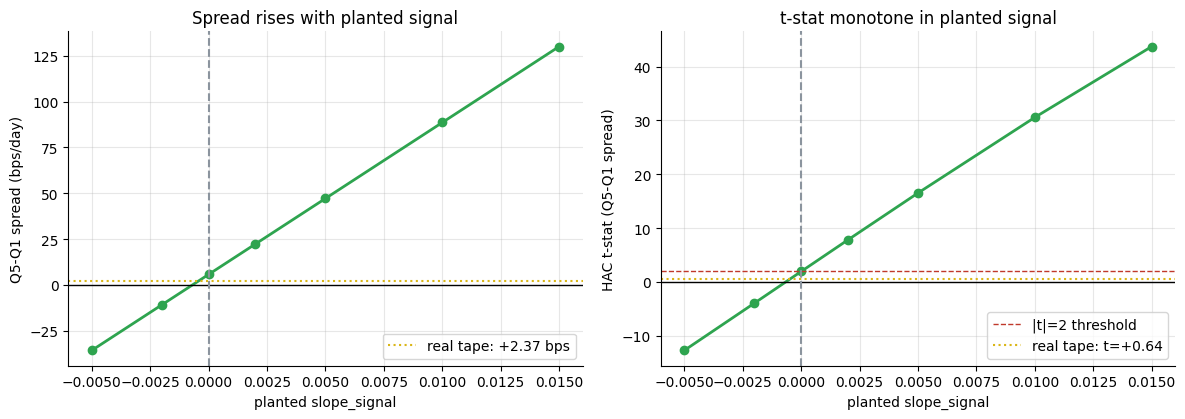

Engine is calibrated: it finds signal when signal is there.


In [7]:
signals = [-0.005, -0.002, 0.0, 0.002, 0.005, 0.010, 0.015]
spreads, t_spr = [], []
for sig in signals:
    df_s, _ = data.synthetic_daily(n_days=5000, slope_signal=sig, seed=132)
    r = st.top_minus_bottom(df_s, horizon=1)
    spreads.append(r['spread_bps'])
    t_spr.append(r['t_spread'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
axes[0].plot(signals, spreads, 'o-', c=GREEN, lw=2)
axes[0].axhline(0, c='k', lw=1); axes[0].axvline(0, ls='--', c=GREY)
axes[0].axhline(2.37, ls=':', c=AMBER, label='real tape: +2.37 bps')
axes[0].set_xlabel('planted slope_signal'); axes[0].set_ylabel('Q5-Q1 spread (bps/day)')
axes[0].set_title('Spread rises with planted signal'); axes[0].legend()
axes[1].plot(signals, t_spr, 'o-', c=GREEN, lw=2)
axes[1].axhline(2, ls='--', c=RED, lw=1, label='|t|=2 threshold')
axes[1].axhline(0, c='k', lw=1); axes[1].axvline(0, ls='--', c=GREY)
axes[1].axhline(0.64, ls=':', c=AMBER, label='real tape: t=+0.64')
axes[1].set_xlabel('planted slope_signal'); axes[1].set_ylabel('HAC t-stat (Q5-Q1 spread)')
axes[1].set_title('t-stat monotone in planted signal'); axes[1].legend()
plt.tight_layout(); plt.show()
print('Engine is calibrated: it finds signal when signal is there.')

The engine is a faithful slope-signal detector. The real-tape amber dot sits in the positive-signal region (directionally right) but well below the t=2 line — which is precisely what 'WEAK' means: a hint of an effect, not a confirmed one. For the signal to clear the bar, it would need to be roughly 3x as large, plausible if the term-premium literature's *monthly* effect also concentrates daily or if a richer signal (forward rates, risk premia) were used.